# Crop interactivo de 4 imagenes embebidas

Este notebook sirve para recortar 4 regiones de una imagen compuesta y aplicar esos mismos recortes a 7 archivos con la misma estructura:

```text
File1/figures/strain_with_roi.png
File2/figures/strain_with_roi.png
...
File7/figures/strain_with_roi.png
```

La idea es seleccionar los 4 crops con el mouse sobre la primera imagen. Como todas las imagenes tienen las mismas dimensiones, esas coordenadas se usan para todos los archivos.

## 1. Imports

In [1]:
from pathlib import Path
import csv
import tkinter as tk
from tkinter import messagebox, ttk

from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import matplotlib.patches as patches


## 2. Activar graficos interactivos

Esta celda permite dibujar rectangulos con el mouse dentro del notebook.

Si aparece un error diciendo que falta `ipympl`, ejecuta `%pip install ipympl`, reinicia el kernel y vuelve a correr desde arriba.

In [2]:
%matplotlib widget


## 3. Configuracion

Aqui va la carpeta que contiene `File1`, `File2`, ..., `File7`.

In [3]:
data_root = Path(r"C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Results reprodicibility experiment")

folder_names = [
    "Scan03_512 - corrected angles",
    "Scan04_512 - corrected angles",
    "Scan05_512 - corrected angles",
    "Scan06_512 - corrected angles",
    "Scan07_512 - corrected angles",
    "Scan08_512 - corrected angles",
    "Scan09_512 - corrected angles",
]

file_folders = [data_root / folder_name for folder_name in folder_names]
input_relative_path = Path("figures") / "strain_with_roi.png"

output_folder_name = "cropped_4_images"
output_extension = ".png"

crop_labels = ["top_left", "top_right", "bottom_left", "bottom_right"]


## 4. Encontrar las imagenes

Esta celda revisa que existan los 7 archivos esperados y muestra sus dimensiones.

In [4]:
image_paths = [folder / input_relative_path for folder in file_folders]
existing_image_paths = [path for path in image_paths if path.exists()]
missing_image_paths = [path for path in image_paths if not path.exists()]
input_folder_name = input_relative_path.parent

print(f"Imagenes encontradas: {len(existing_image_paths)} de {len(image_paths)}")

for path in existing_image_paths:
    with Image.open(path) as image:
        print(f"- OK: {path.relative_to(data_root)}: {image.size[0]} x {image.size[1]} px")

if missing_image_paths:
    print("\nNo encontradas:")
    for path in missing_image_paths:
        print(f"- Falta: {path.relative_to(data_root)}")

    print(f"\nImagenes disponibles dentro de cada carpeta {input_folder_name}:")
    for folder in file_folders:
        image_dir = folder / input_folder_name
        print(f"\n{folder.name}/{input_folder_name}")

        if not image_dir.exists():
            print(f"  No existe la carpeta {input_folder_name}")
            continue

        available_images = sorted(
            list(image_dir.glob("*.png"))
            + list(image_dir.glob("*.jpg"))
            + list(image_dir.glob("*.jpeg"))
            + list(image_dir.glob("*.tif"))
            + list(image_dir.glob("*.tiff"))
        )

        if not available_images:
            print("  No hay imagenes en esta carpeta")
        else:
            for image_path in available_images:
                print(f"  - {image_path.name}")

if not existing_image_paths:
    raise FileNotFoundError("No se encontro ninguna imagen. Revisa data_root, folder_names o input_relative_path.")


Imagenes encontradas: 7 de 7
- OK: Scan03_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan04_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan05_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan06_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan07_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan08_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px
- OK: Scan09_512 - corrected angles\figures\strain_with_roi.png: 1674 x 462 px


## 5. Seleccionar y editar los 4 crops en una ventana

Esta celda abre una ventana separada para seleccionar los crops con mas control.

1. Elige el cuadrante que quieres editar.
2. Dibuja un rectangulo sobre la imagen con click izquierdo y arrastrando.
3. Si no queda bien, vuelve a dibujarlo: reemplaza solo ese cuadrante.
4. Si quieres que todos tengan el mismo tamano, dibuja primero un crop con el tamano correcto y presiona `Usar tamano actual para todos`. Despues, al dibujar otros cuadrantes, se conserva ese mismo ancho y alto.
5. Cuando termines, presiona `Terminar y guardar coordenadas`, cierra la ventana y ejecuta la siguiente celda.

In [5]:
selected_crop_boxes = {}
preview_path = existing_image_paths[0]
preview_image = Image.open(preview_path)
image_width, image_height = preview_image.size

max_display_width = 1100
max_display_height = 850
display_scale = min(max_display_width / image_width, max_display_height / image_height, 1.0)
display_size = (int(image_width * display_scale), int(image_height * display_scale))
display_image = preview_image.resize(display_size, Image.Resampling.LANCZOS)

root = tk.Tk()
root.title(f"Editor de crops - {preview_path.relative_to(data_root)}")
root.geometry("1400x950")

active_crop_label = tk.StringVar(value=crop_labels[0])
equal_size_enabled = tk.BooleanVar(value=False)
equal_crop_size = None
drag_start = None
preview_rect_id = None
crop_canvas_items = {}

main_frame = ttk.Frame(root, padding=8)
main_frame.pack(fill="both", expand=True)

canvas_frame = ttk.Frame(main_frame)
canvas_frame.pack(side="left", fill="both", expand=True)

canvas = tk.Canvas(
    canvas_frame,
    width=display_size[0],
    height=display_size[1],
    background="black",
    highlightthickness=0,
)
canvas.pack(fill="both", expand=True)

tk_image = ImageTk.PhotoImage(display_image)
canvas.create_image(0, 0, anchor="nw", image=tk_image)
canvas.config(scrollregion=(0, 0, display_size[0], display_size[1]))

control_frame = ttk.Frame(main_frame, padding=(12, 0, 0, 0), width=260)
control_frame.pack(side="right", fill="y")
control_frame.pack_propagate(False)

status_var = tk.StringVar()
size_var = tk.StringVar(value="Tamano comun: no fijado")


def image_to_canvas_box(box):
    left, upper, right, lower = box
    return (
        left * display_scale,
        upper * display_scale,
        right * display_scale,
        lower * display_scale,
    )


def canvas_to_image_point(x, y):
    image_x = int(round(max(0, min(x / display_scale, image_width))))
    image_y = int(round(max(0, min(y / display_scale, image_height))))
    return image_x, image_y


def get_box_size(box):
    left, upper, right, lower = box
    return right - left, lower - upper


def clamp_fixed_size_box(left, upper, width, height):
    width = min(width, image_width)
    height = min(height, image_height)
    left = max(0, min(left, image_width - width))
    upper = max(0, min(upper, image_height - height))
    return (left, upper, left + width, upper + height)


def make_box(start, end, commit_equal_size=False):
    global equal_crop_size

    start_x, start_y = start
    end_x, end_y = end
    left, right = sorted([start_x, end_x])
    upper, lower = sorted([start_y, end_y])

    if equal_size_enabled.get() and equal_crop_size is not None:
        return clamp_fixed_size_box(left, upper, *equal_crop_size)

    box = (left, upper, right, lower)
    if equal_size_enabled.get() and equal_crop_size is None and commit_equal_size:
        width, height = get_box_size(box)
        if width > 0 and height > 0:
            equal_crop_size = (width, height)
            size_var.set(f"Tamano comun: {width} x {height} px")
            print(f"Tamano comun fijado: {width} x {height} px")

    return box


def update_status():
    selected = " | ".join(
        f"{label}: OK" if label in selected_crop_boxes else f"{label}: pendiente"
        for label in crop_labels
    )
    status_var.set(f"Activo: {active_crop_label.get()}\n{selected}")


def draw_crop(label):
    for item_id in crop_canvas_items.pop(label, []):
        canvas.delete(item_id)

    if label not in selected_crop_boxes:
        return

    left, upper, right, lower = image_to_canvas_box(selected_crop_boxes[label])
    rect_id = canvas.create_rectangle(
        left,
        upper,
        right,
        lower,
        outline="yellow",
        width=3,
        tags=("crop", label),
    )
    text_id = canvas.create_text(
        left + 8,
        upper + 18,
        anchor="w",
        text=label,
        fill="yellow",
        font=("Segoe UI", 12, "bold"),
        tags=("crop", label),
    )
    crop_canvas_items[label] = [rect_id, text_id]


def redraw_all_crops():
    for label in crop_labels:
        draw_crop(label)


def apply_common_size_to_existing():
    if equal_crop_size is None:
        return

    width, height = equal_crop_size
    for label, box in list(selected_crop_boxes.items()):
        left, upper, _, _ = box
        selected_crop_boxes[label] = clamp_fixed_size_box(left, upper, width, height)
    redraw_all_crops()
    update_status()


def set_common_size_from_current():
    global equal_crop_size

    label = active_crop_label.get()
    if label not in selected_crop_boxes:
        messagebox.showinfo("Tamano igual", "Primero dibuja el crop activo para usarlo como tamano comun.")
        return

    equal_crop_size = get_box_size(selected_crop_boxes[label])
    equal_size_enabled.set(True)
    size_var.set(f"Tamano comun: {equal_crop_size[0]} x {equal_crop_size[1]} px")
    apply_common_size_to_existing()
    print(f"Tamano comun fijado desde {label}: {equal_crop_size[0]} x {equal_crop_size[1]} px")


def clear_common_size():
    global equal_crop_size

    equal_crop_size = None
    equal_size_enabled.set(False)
    size_var.set("Tamano comun: no fijado")
    update_status()


def clear_current_crop():
    label = active_crop_label.get()
    selected_crop_boxes.pop(label, None)
    for item_id in crop_canvas_items.pop(label, []):
        canvas.delete(item_id)
    update_status()


def clear_all_crops():
    selected_crop_boxes.clear()
    for label in list(crop_canvas_items):
        for item_id in crop_canvas_items.pop(label, []):
            canvas.delete(item_id)
    clear_common_size()
    update_status()


def on_mouse_down(event):
    global drag_start, preview_rect_id

    drag_start = canvas_to_image_point(event.x, event.y)
    if preview_rect_id is not None:
        canvas.delete(preview_rect_id)
        preview_rect_id = None


def on_mouse_drag(event):
    global preview_rect_id

    if drag_start is None:
        return

    current = canvas_to_image_point(event.x, event.y)
    box = make_box(drag_start, current, commit_equal_size=False)
    left, upper, right, lower = image_to_canvas_box(box)

    if preview_rect_id is not None:
        canvas.delete(preview_rect_id)
    preview_rect_id = canvas.create_rectangle(
        left,
        upper,
        right,
        lower,
        outline="cyan",
        width=2,
        dash=(4, 3),
    )


def on_mouse_up(event):
    global drag_start, preview_rect_id

    if drag_start is None:
        return

    current = canvas_to_image_point(event.x, event.y)
    box = make_box(drag_start, current, commit_equal_size=True)
    drag_start = None

    if preview_rect_id is not None:
        canvas.delete(preview_rect_id)
        preview_rect_id = None

    if box[2] <= box[0] or box[3] <= box[1]:
        print("Crop ignorado: el rectangulo no tiene area.")
        return

    label = active_crop_label.get()
    selected_crop_boxes[label] = box
    draw_crop(label)
    update_status()
    print(f"{label}: {box}")


def finish_and_close():
    missing = [label for label in crop_labels if label not in selected_crop_boxes]
    if missing:
        messagebox.showwarning("Faltan crops", "Todavia faltan: " + ", ".join(missing))
        return

    print("Coordenadas guardadas en selected_crop_boxes:")
    for label in crop_labels:
        print(f"  {label}: {selected_crop_boxes[label]}")
    root.destroy()


ttk.Label(control_frame, text="Cuadrante activo", font=("Segoe UI", 11, "bold")).pack(anchor="w")
for label in crop_labels:
    ttk.Radiobutton(
        control_frame,
        text=label,
        variable=active_crop_label,
        value=label,
        command=update_status,
    ).pack(anchor="w", pady=2)

ttk.Separator(control_frame).pack(fill="x", pady=12)
ttk.Checkbutton(
    control_frame,
    text="Usar tamano comun",
    variable=equal_size_enabled,
    command=apply_common_size_to_existing,
).pack(anchor="w")
ttk.Button(
    control_frame,
    text="Usar tamano actual para todos",
    command=set_common_size_from_current,
).pack(fill="x", pady=(8, 4))
ttk.Button(
    control_frame,
    text="Quitar tamano comun",
    command=clear_common_size,
).pack(fill="x", pady=4)
ttk.Label(control_frame, textvariable=size_var, wraplength=230).pack(anchor="w", pady=(4, 0))

ttk.Separator(control_frame).pack(fill="x", pady=12)
ttk.Button(control_frame, text="Borrar cuadrante activo", command=clear_current_crop).pack(fill="x", pady=4)
ttk.Button(control_frame, text="Borrar todo", command=clear_all_crops).pack(fill="x", pady=4)

ttk.Separator(control_frame).pack(fill="x", pady=12)
ttk.Label(control_frame, textvariable=status_var, wraplength=230, justify="left").pack(anchor="w")
ttk.Button(
    control_frame,
    text="Terminar y guardar coordenadas",
    command=finish_and_close,
).pack(fill="x", pady=(18, 4))

canvas.bind("<ButtonPress-1>", on_mouse_down)
canvas.bind("<B1-Motion>", on_mouse_drag)
canvas.bind("<ButtonRelease-1>", on_mouse_up)

update_status()
print("Se abrio una ventana para editar los crops. No avanza automaticamente entre cuadrantes.")
root.mainloop()


Se abrio una ventana para editar los crops. No avanza automaticamente entre cuadrantes.
top_left: (5, 3, 313, 361)
Tamano comun fijado: 344 x 347 px
top_left: (323, 8, 667, 355)
top_left: (0, 3, 344, 350)
top_left: (0, 0, 344, 347)
top_left: (3, 5, 347, 352)
top_left: (370, 6, 714, 353)
top_left: (14, 12, 309, 358)
top_left: (14, 15, 18, 23)
top_left: (8, 12, 307, 350)
Crop ignorado: el rectangulo no tiene area.
top_left: (3, 12, 312, 347)
Tamano comun fijado desde top_left: 309 x 335 px
Tamano comun fijado desde top_left: 309 x 335 px
Tamano comun fijado desde top_left: 309 x 335 px
top_right: (431, 68, 740, 403)
top_right: (352, 35, 661, 370)
top_right: (355, 17, 664, 352)
top_right: (352, 17, 661, 352)
top_right: (342, 15, 651, 350)
top_right: (342, 15, 651, 350)
top_right: (342, 15, 651, 350)
top_right: (342, 11, 651, 346)
bottom_left: (686, 26, 995, 361)
bottom_left: (686, 26, 995, 361)
bottom_left: (686, 15, 995, 350)
bottom_left: (686, 18, 995, 353)
bottom_left: (686, 15, 995, 3

## 6. Fijar las coordenadas seleccionadas

Ejecuta esta celda despues de dibujar los 4 rectangulos.

In [6]:
if len(selected_crop_boxes) != 4:
    raise ValueError(f"Seleccionaste {len(selected_crop_boxes)} crops, pero se necesitan 4.")

crop_boxes = {label: selected_crop_boxes[label] for label in crop_labels}
crop_boxes


{'top_left': (3, 12, 312, 347),
 'top_right': (342, 11, 651, 346),
 'bottom_left': (682, 12, 991, 347),
 'bottom_right': (1020, 9, 1329, 344)}

## 7. Preview final

Esta celda muestra las cajas finales sobre la primera imagen antes de guardar.

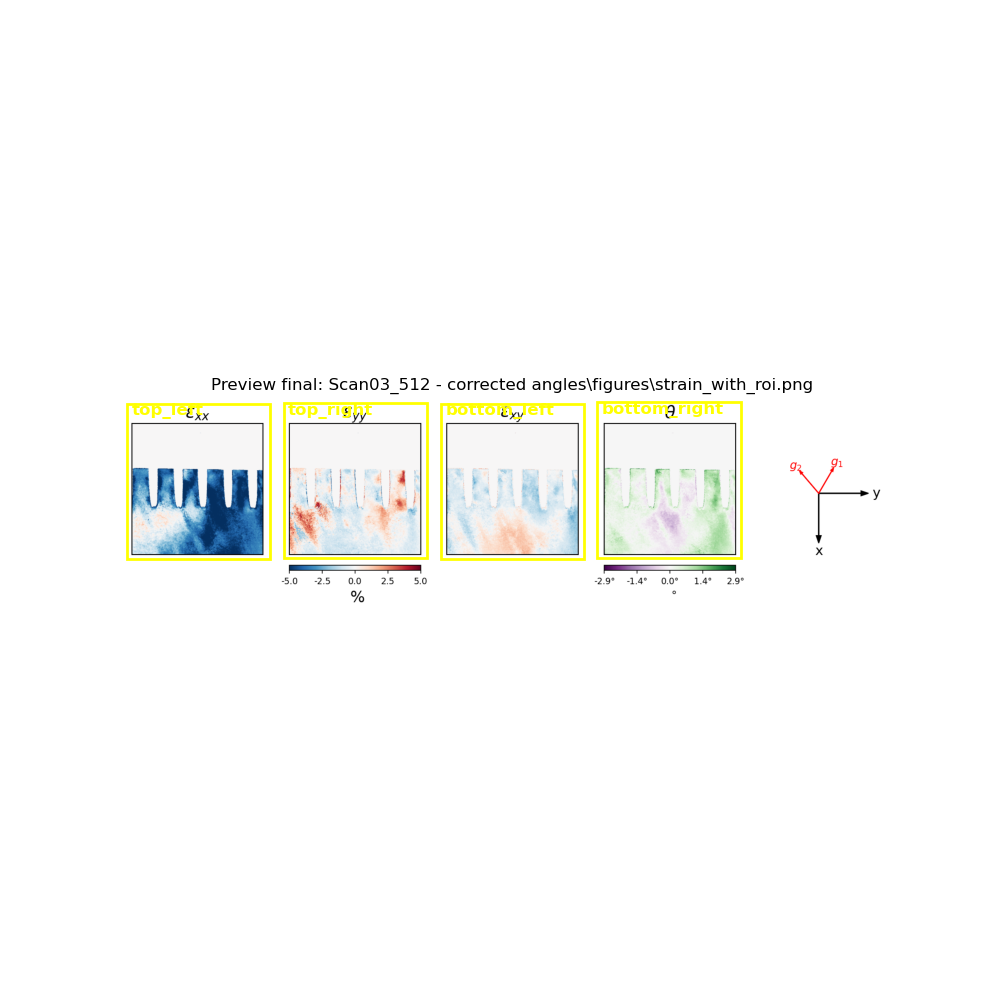

In [7]:
with Image.open(preview_path) as preview_image:
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(preview_image)
    ax.set_title(f"Preview final: {preview_path.relative_to(data_root)}")
    ax.axis("off")

    for label, (left, upper, right, lower) in crop_boxes.items():
        rect = patches.Rectangle(
            (left, upper),
            right - left,
            lower - upper,
            linewidth=2,
            edgecolor="yellow",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(left + 10, upper + 25, label, color="yellow", fontsize=12, weight="bold")

    plt.show()


## 8. Guardar los crops

Esta celda aplica los mismos 4 recortes a todas las imagenes encontradas y guarda los resultados en `FileX/figures/cropped_4_images/`.

In [8]:
saved_rows = []

for image_path in existing_image_paths:
    output_dir = image_path.parent / output_folder_name
    output_dir.mkdir(parents=True, exist_ok=True)

    with Image.open(image_path) as image:
        for label, box in crop_boxes.items():
            cropped = image.crop(box)
            output_path = output_dir / f"{image_path.stem}_{label}{output_extension}"
            cropped.save(output_path)

            saved_rows.append({
                "source": str(image_path.relative_to(data_root)),
                "crop_label": label,
                "box_left": box[0],
                "box_upper": box[1],
                "box_right": box[2],
                "box_lower": box[3],
                "output": str(output_path.relative_to(data_root)),
            })

manifest_path = data_root / "crop_4_embedded_images_manifest.csv"
with manifest_path.open("w", newline="", encoding="utf-8") as manifest_file:
    fieldnames = ["source", "crop_label", "box_left", "box_upper", "box_right", "box_lower", "output"]
    writer = csv.DictWriter(manifest_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(saved_rows)

print(f"Crops guardados: {len(saved_rows)}")
print(f"Manifest: {manifest_path}")
for row in saved_rows[:8]:
    print(f"- {row['output']}")


Crops guardados: 28
Manifest: C:\Users\jtapiaca.ASURITE\Desktop\S3\05152026 - S3\Results reprodicibility experiment\crop_4_embedded_images_manifest.csv
- Scan03_512 - corrected angles\figures\cropped_4_images\strain_with_roi_top_left.png
- Scan03_512 - corrected angles\figures\cropped_4_images\strain_with_roi_top_right.png
- Scan03_512 - corrected angles\figures\cropped_4_images\strain_with_roi_bottom_left.png
- Scan03_512 - corrected angles\figures\cropped_4_images\strain_with_roi_bottom_right.png
- Scan04_512 - corrected angles\figures\cropped_4_images\strain_with_roi_top_left.png
- Scan04_512 - corrected angles\figures\cropped_4_images\strain_with_roi_top_right.png
- Scan04_512 - corrected angles\figures\cropped_4_images\strain_with_roi_bottom_left.png
- Scan04_512 - corrected angles\figures\cropped_4_images\strain_with_roi_bottom_right.png


## 9. Verificar resultados

Muestra los crops guardados para el primer archivo.

In [ ]:
first_output_dir = existing_image_paths[0].parent / output_folder_name
generated = sorted(first_output_dir.glob(f"*{output_extension}"))

if not generated:
    print("Todavia no hay crops guardados. Ejecuta la celda anterior primero.")
else:
    fig, axes = plt.subplots(1, len(generated), figsize=(4 * len(generated), 4))
    if len(generated) == 1:
        axes = [axes]

    for ax, path in zip(axes, generated):
        with Image.open(path) as image:
            ax.imshow(image)
        ax.set_title(path.stem)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
